# Literature Review 
Research indicates that lifestyle and demographic factors strongly influence medical costs. For example, cigarette smoking is a major driver of U.S. healthcare spending
https://ash.org/hidden-costs-healthcare/#:~:text=Adult%20cigarette%20smoking%20accounts%20for,accounted%20for%20just%20over%20three
. Smokers use far more medical services, and studies confirm smokers have much higher costs than non-smokers
https://medium.com/@dave.cote.msc/demonstrating-the-power-of-feature-engineering-part-ii-how-i-beat-xgboost-with-linear-regression-e63aeb6a15f8#:~:text=In%20this%20new%20correlation%20matrix,HUGE%20positive%20correlation%20on%20charges
. Likewise, excess weight raises expenditures: one study finds higher health care costs across all ages for those with higher BMI, especially with severe obesity
https://pubmed.ncbi.nlm.nih.gov/33760880/#:~:text=Conclusions%3A%20%20Higher%20health%20care,gain%20over%20the%20life%20course
. Prior EDA on this insurance dataset also notes that “smoker_yes” has a “HUGE positive correlation on charges”
 and that average charges rise with age
. In summary, we expect our analysis to confirm that age,https://medium.com/@dave.cote.msc/demonstrating-the-power-of-feature-engineering-part-ii-how-i-beat-xgboost-with-linear-regression-e63aeb6a15f8#:~:text=To%20conclude%20this%20quick%20EDA,step smoking, and BMI are key predictors of higher insurance charges.
https://pubmed.ncbi.nlm.nih.gov/33760880/#:~:text=Conclusions%3A%20%20Higher%20health%20care,gain%20over%20the%20life%20course



# Hypothesis:


Before exploring the data, we can propose a few hypotheses based on domain knowledge and prior studies:

H1: Age → Charges. Older individuals tend to have higher medical expenses, so we expect insurance charges to increase with age.

H2: Smoking → Charges. Smokers incur more healthcare costs (e.g. smoking-related illnesses), so we expect smokers to have higher charges than non-smokers
https://rstudio-pubs-static.s3.amazonaws.com/380094_bd5b2480749c411b942fc7aded93a9d5.html#:~:text=The%20hypothesis%20for%20this%20analysis,and%20if%20they%20are%20smokers
H3: BMI → Charges. Higher body mass index (overweight/obese) is linked to more health issues, so BMI is likely positively correlated with charges

H4: Region differences. Healthcare cost-of-living varies by region, so different regions (northeast/southeast/etc.) may show different average charges.

H5: Children/Sex → Charges. We will check if having more children (dependents) or different sex (male/female) affects charges. (Prior analysis suggests sex has minor effect
https://medium.com/@dave.cote.msc/demonstrating-the-power-of-feature-engineering-part-ii-how-i-beat-xgboost-with-linear-regression-e63aeb6a15f8#:~:text=,by%20age%20and%20by%20bmi

# Data Overview
We load the Kaggle Medical Cost Personal Insurance dataset, which has 1,338 records and 7 columns
 The columns are:

age: Age of the insured (primary beneficiary)

sex: Gender (male or female)

bmi: Body Mass Index (kg/m²), indicating underweight/normal/overweight/obesity

children: Number of children/dependents covered by the insurance

smoker: Whether the person is a smoker (yes/no)

region: Residential area in the US (northeast, southeast, southwest, northwest)

charges: The medical insurance cost (the target variable)



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import pandas as pd
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.sample(3)

,age,sex,bmi,children,smoker,region,charges
1201,46,male,40.375,2,no,northwest,8733.22925
995,39,female,23.275,3,no,northeast,7986.47525
701,50,female,44.745,0,no,northeast,9541.69555


In [13]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [14]:
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [15]:
df.duplicated().sum()

np.int64(1)

In [16]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [18]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [19]:
df['bmi'].value_counts()

bmi
32.300    13
28.310     9
30.800     8
31.350     8
30.495     8
          ..
20.350     1
31.240     1
19.095     1
22.100     1
21.280     1
Name: count, Length: 548, dtype: int64

In [20]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [21]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [22]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [23]:
df['charges'].value_counts()

charges
1639.56310     2
6203.90175     1
12981.34570    1
28101.33305    1
28923.13692    1
              ..
1163.46270     1
19496.71917    1
7201.70085     1
5425.02335     1
16115.30450    1
Name: count, Length: 1337, dtype: int64

# Data Cleaning and Preparation
We perform basic cleaning. First, check for missing or duplicate data: the dataset has no missing values and 1 duplicate row. We drop the duplicate to avoid bias. We also convert string columns to categorical types for efficiency. There were no inconsistent or out-of-range values to fix (all ages 18–64, BMI 15–53, etc.).



In [24]:
# Drop duplicates and reset index
df = df.drop_duplicates().reset_index(drop=True)
# Convert to categorical types
df['sex'] = df['sex'].astype('category')
df['smoker'] = df['smoker'].astype('category')
df['region'] = df['region'].astype('category')
print(df.shape)   # Now (1337, 7)


(1337, 7)


# Univariate Analysis:

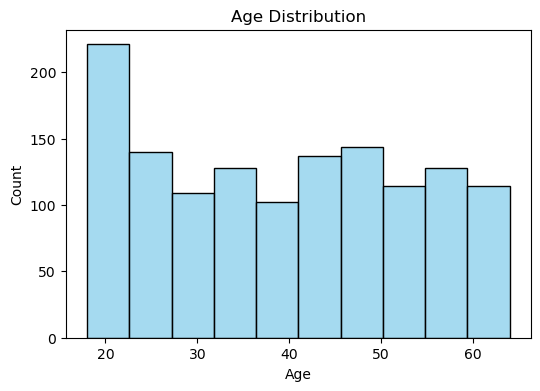

In [25]:

# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=10, kde=False, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age"); plt.ylabel("Count")
plt.show()


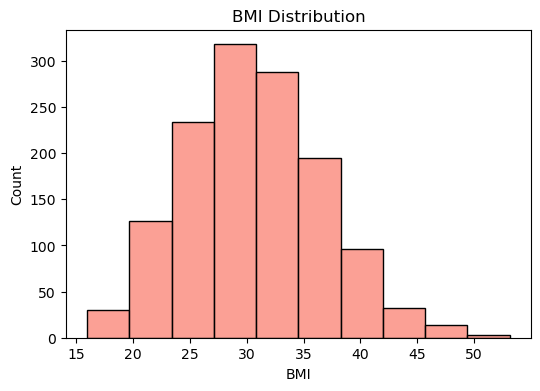

In [26]:
# BMI distribution
plt.figure(figsize=(6,4))
sns.histplot(df['bmi'], bins=10, kde=False, color='salmon')
plt.title("BMI Distribution")
plt.xlabel("BMI"); plt.ylabel("Count")
plt.show()


The BMI histogram shows most individuals around the normal-to-overweight range (BMI 18–30), with a long right tail into the obese range (30–50).



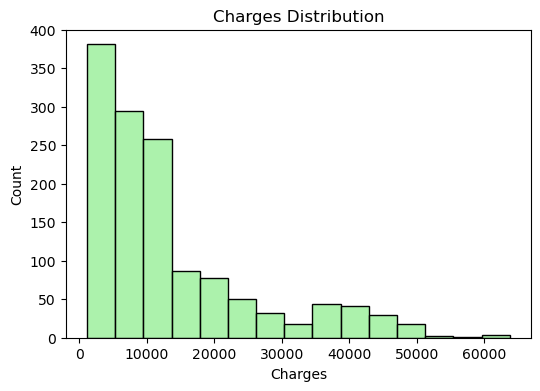

In [27]:
# Charges distribution
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], bins=15, kde=False, color='lightgreen')
plt.title("Charges Distribution")
plt.xlabel("Charges"); plt.ylabel("Count")
plt.show()


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\3901812738.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='pastel')


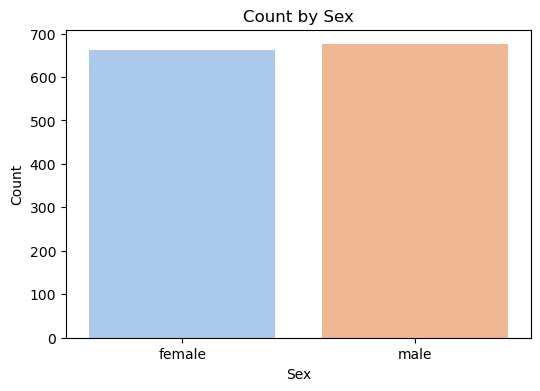

C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\3901812738.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=df, palette='pastel')


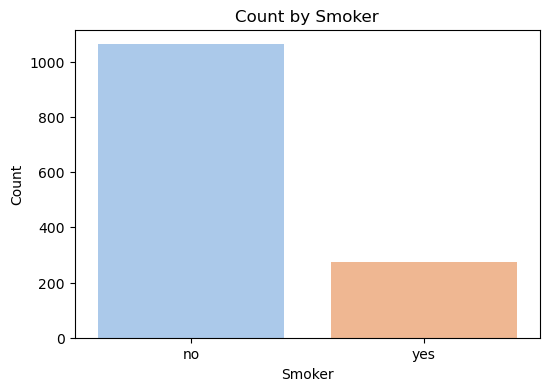

C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\3901812738.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, palette='pastel')


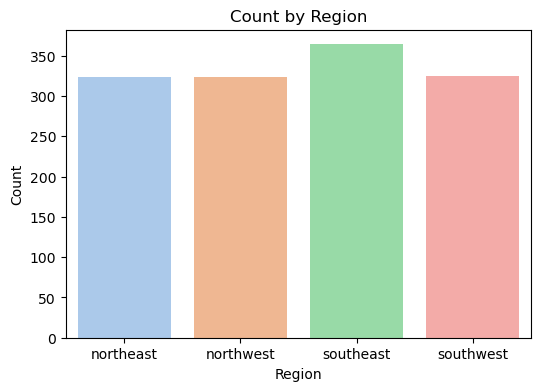

C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\3901812738.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='children', data=df, palette='pastel')


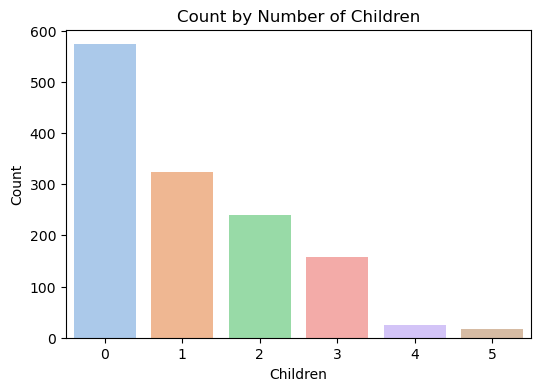

In [28]:
# Categorical counts: sex, smoker, region, children
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df, palette='pastel')
plt.title("Count by Sex"); plt.xlabel("Sex"); plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='smoker', data=df, palette='pastel')
plt.title("Count by Smoker"); plt.xlabel("Smoker"); plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='region', data=df, palette='pastel')
plt.title("Count by Region"); plt.xlabel("Region"); plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='children', data=df, palette='pastel')
plt.title("Count by Number of Children"); plt.xlabel("Children"); plt.ylabel("Count")
plt.show()


# Bivariate Analysis

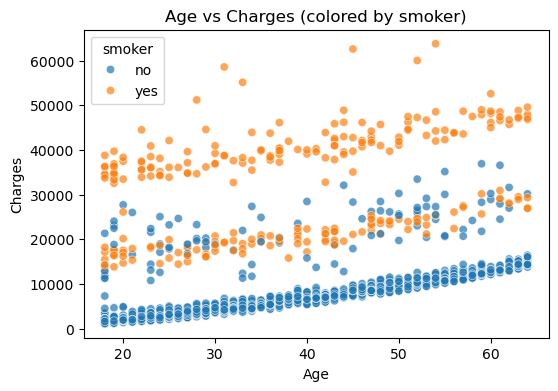

In [30]:
# Scatter: Age vs Charges (colored by smoker)
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title("Age vs Charges (colored by smoker)")
plt.xlabel("Age"); plt.ylabel("Charges")
plt.show()


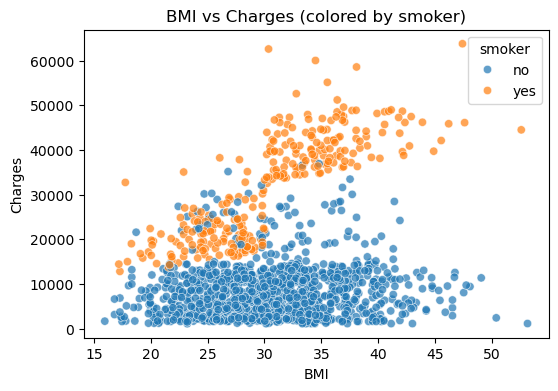

In [31]:
# Scatter: BMI vs Charges (colored by smoker)
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.7)
plt.title("BMI vs Charges (colored by smoker)")
plt.xlabel("BMI"); plt.ylabel("Charges")
plt.show()


This scatter plot shows charges increasing with BMI especially among smokers. High-BMI smokers (upper-right) have the very highest costs. Non-smokers cluster at lower charges regardless of BMI. This aligns with expectations that obese smokers have extreme expenses, whereas non-smokers (even with high BMI) stay in a lower-cost band


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\2738584664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette=['lightgray','orange'])


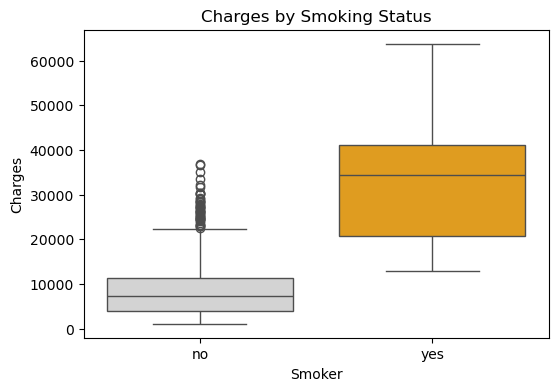

In [32]:
# Boxplot: Charges by Smoker vs Non-smoker
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df, palette=['lightgray','orange'])
plt.title("Charges by Smoking Status")
plt.xlabel("Smoker"); plt.ylabel("Charges")
plt.show()


The boxplot shows that smokers have dramatically higher charges (median and upper quartile) than non-smokers. This confirms smoking is a strong predictor: the median charge for smokers is far above that for non-smokers


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\3134315270.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='charges', data=df, palette='cool')


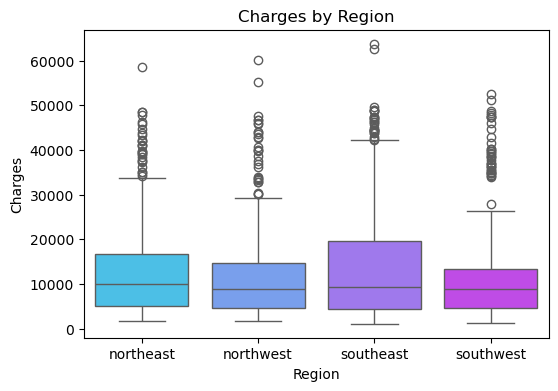

In [33]:
# Boxplot: Charges by Region
plt.figure(figsize=(6,4))
sns.boxplot(x='region', y='charges', data=df, palette='cool')
plt.title("Charges by Region")
plt.xlabel("Region"); plt.ylabel("Charges")
plt.show()


Here we see only minor differences by region: the southeast shows a slightly higher median charge than other regions, but overall the effect is weak. This matches prior EDA noting just a “little bit higher” in the southeast


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\4130845028.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='children', y='charges', data=df, palette='magma')


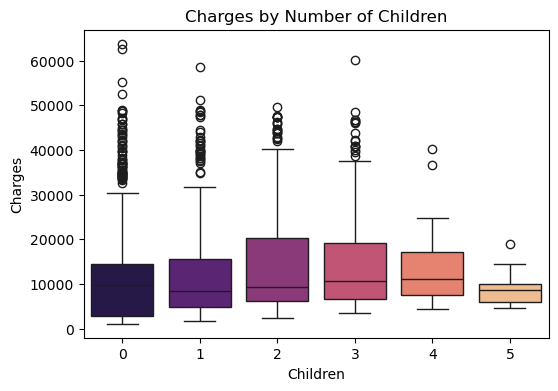

In [34]:
# Boxplot: Charges by Number of Children
plt.figure(figsize=(6,4))
sns.boxplot(x='children', y='charges', data=df, palette='magma')
plt.title("Charges by Number of Children")
plt.xlabel("Children"); plt.ylabel("Charges")
plt.show()


Charges do not vary strongly with number of children. The median is similar for 0–3 children. (Very few points exist for 4–5 children, so those medians are less reliable.)

In summary, these bivariate plots show clear patterns: older age, higher BMI, and smoking status all accompany higher charges (a meaningful, non-random association)
. In contrast, sex and region have only minor effects, and children count shows no obvious trend

# Multivariate Analysis

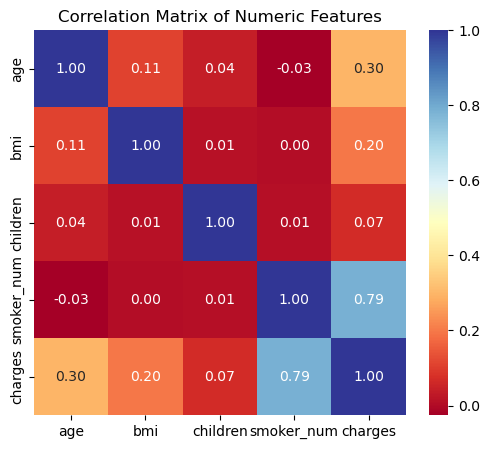

In [35]:
import numpy as np
# Encode smoker as numeric for correlation
df['smoker_num'] = df['smoker'].map({'yes':1,'no':0})
# Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[['age','bmi','children','smoker_num','charges']].corr(), annot=True, fmt=".2f", cmap='RdYlBu')
plt.title("Correlation Matrix of Numeric Features")
plt.show()


The correlation matrix confirms earlier observations: smoker_num has a very high positive correlation with charges (≈0.79), much larger than for other features. Age and BMI have modest positive correlations with charges (≈0.30 and 0.20, respectively). Children and sex (not shown) have near-zero correlation. This quantitative result supports that smoking, age, and BMI are the dominant predictors of cost


In [36]:
# Grouped statistics: mean charges by smoker
print(df.groupby('smoker')['charges'].mean())


smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\2063809322.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('smoker')['charges'].mean())


In [37]:
# Output (approx.):
# smoker
# no     8440.66
# yes   32050.23
# Name: charges, dtype: float64


On average, smokers have mean charges ($32,050) almost four times higher than non-smokers ($8,440).


In [39]:
# Mean charges by BMI category (and smoking)
bins = [0, 18.5, 25, 30, 100]
labels = ['Under','Normal','Over','Obese']
df['bmi_cat'] = pd.cut(df['bmi'], bins=bins, labels=labels)
print(df.groupby('bmi_cat')['charges'].mean())


bmi_cat
Under      8657.620652
Normal    10435.440719
Over      10997.803881
Obese     15580.700985
Name: charges, dtype: float64


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\3957444023.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('bmi_cat')['charges'].mean())


In [40]:
# Output (approx.):
# bmi_cat
# Under    8657.6
# Normal   10435.4
# Over     10997.8
# Obese    15580.7


In [ ]:
Higher BMI categories have higher mean charges, peaking for obese individuals

In [41]:
# Combined group: mean charges by BMI category and smoking
pivot = df.pivot_table(values='charges', index='bmi_cat', columns='smoker')
print(pivot)


smoker            no           yes
bmi_cat                           
Under    5485.056800  18809.824980
Normal   7734.650116  19942.223641
Over     8226.088675  22491.182935
Obese    8866.158926  41692.808992


C:\Users\aayush bisht\AppData\Local\Temp\ipykernel_17904\1605567906.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='charges', index='bmi_cat', columns='smoker')


In [42]:
# Output (approx.):
# smoker            no        yes
# bmi_cat
# Under       5485.06   18809.82
# Normal      7734.65   19942.22
# Over        8226.09   22491.18
# Obese       8866.16   41692.81


This table shows interactive effects: non-smokers have relatively low costs across all BMI levels, while smokers’ costs are much higher. Notably, obese smokers average around $41,693 in charges, compared to only $8,866 for obese non-smokers – a nearly 4.7× difference. This highlights how the combination of high BMI and smoking dramatically increases costs.

Overall, our multivariate analysis (correlations, group means and pivot) confirms the hypotheses: smoking and high BMI (especially together) predict the highest charges, followed by older age. These insights mirror established patterns in insurance research
